# Cargar datos y filtrar los de automovil

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pandas.plotting import scatter_matrix


In [2]:
df = pd.read_excel("Prestamos_Data_Alumnos_v5.xlsx")


In [3]:
df['Proposito'].value_counts()

Proposito
Educación    178609
Vivienda     101899
Automóvil     76930
Otros         76748
Negocios      76515
Name: count, dtype: int64

In [4]:
df_auto = df[df["Proposito"] == "Automóvil"].copy()


# Revision general

In [5]:
df_auto.head()


,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,O77MPJ,26,19153.0,6973,706,9.0,1,19.05,36.0,0.10,Grado Universitario,Jornada completa,Soltero,0.0,1.0,Automóvil,1.0,1,130.83
8,IYOL1S,29,39531.0,40000,826,0.0,1,9.74,24.0,0.19,Doctorado,Jornada completa,Casado,0.0,0.0,Automóvil,1.0,0,208.64
9,FRMZVN,29,40348.0,16448,740,9.0,1,14.73,24.0,0.10,Máster,Jornada completa,Soltero,0.0,1.0,Automóvil,0.0,1,101.94
26,YKHXVY,38,41732.0,42040,661,173.0,2,13.24,48.0,0.18,Grado Universitario,Tiempo parcial,Casado,1.0,0.0,Automóvil,1.0,1,800.00
32,NHDJTK,35,35085.0,16406,759,181.0,1,9.74,36.0,0.13,Escolar,Jornada completa,Casado,0.0,1.0,Automóvil,0.0,0,94.42


In [6]:
df_auto.info()


<class 'pandas.DataFrame'>
Index: 76930 entries, 0 to 510700
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    76930 non-null  str    
 1   Edad                  76930 non-null  int64  
 2   Ingresos              76930 non-null  float64
 3   Monto_Inicial         76930 non-null  int64  
 4   Scoring_Crediticio    76930 non-null  int64  
 5   Meses_Empleo          76929 non-null  float64
 6   Num_Creditos          76930 non-null  int64  
 7   Ratio_Interes         76930 non-null  float64
 8   Duracion              76929 non-null  float64
 9   Ratio_Deuda_Ingresos  76929 non-null  float64
 10  Estudios              76930 non-null  str    
 11  Tipo_Jornada_Laboral  76930 non-null  str    
 12  Estado_Civil          76929 non-null  str    
 13  Posesion_Hipoteca     76930 non-null  float64
 14  Personas_Cargo        76930 non-null  float64
 15  Proposito             76930 non-nu

In [7]:
df_auto.dtypes

ID                          str
Edad                      int64
Ingresos                float64
Monto_Inicial             int64
Scoring_Crediticio        int64
Meses_Empleo            float64
Num_Creditos              int64
Ratio_Interes           float64
Duracion                float64
Ratio_Deuda_Ingresos    float64
Estudios                    str
Tipo_Jornada_Laboral        str
Estado_Civil                str
Posesion_Hipoteca       float64
Personas_Cargo          float64
Proposito                   str
Fiador                  float64
Impago                    int64
Prima                   float64
dtype: object

In [8]:
df_auto.duplicated().sum()

np.int64(1)

In [9]:
df_auto = df_auto.drop_duplicates()


# Valores faltantes

In [10]:
df_auto.isnull().sum()


ID                      0
Edad                    0
Ingresos                0
Monto_Inicial           0
Scoring_Crediticio      0
Meses_Empleo            1
Num_Creditos            0
Ratio_Interes           0
Duracion                1
Ratio_Deuda_Ingresos    1
Estudios                0
Tipo_Jornada_Laboral    0
Estado_Civil            1
Posesion_Hipoteca       0
Personas_Cargo          0
Proposito               0
Fiador                  1
Impago                  0
Prima                   1
dtype: int64

In [11]:
df_auto = df_auto.dropna()


In [ ]:
# df_auto.to_csv("prestamos_automovil.csv", index=False)

In [13]:
df_auto.isnull().sum()


ID                      0
Edad                    0
Ingresos                0
Monto_Inicial           0
Scoring_Crediticio      0
Meses_Empleo            0
Num_Creditos            0
Ratio_Interes           0
Duracion                0
Ratio_Deuda_Ingresos    0
Estudios                0
Tipo_Jornada_Laboral    0
Estado_Civil            0
Posesion_Hipoteca       0
Personas_Cargo          0
Proposito               0
Fiador                  0
Impago                  0
Prima                   0
dtype: int64

# variables categoricas 

In [14]:
df_auto["Personas_Cargo"] = df_auto["Personas_Cargo"].astype(int).astype(str)
#era float por que quiza en el df completo tenai algun nulo

In [15]:
df_auto["Personas_Cargo"].value_counts()

Personas_Cargo
0    42388
1    34536
Name: count, dtype: int64

In [16]:
df_auto["Estudios"].value_counts()

Estudios
Escolar                29989
Grado Universitario    28626
Máster                 12297
Doctorado               6012
Name: count, dtype: int64

In [17]:
df_auto["Tipo_Jornada_Laboral"].value_counts()

Tipo_Jornada_Laboral
Jornada completa    42100
Tiempo parcial      15429
Autónomo            11593
Desempleado          7802
Name: count, dtype: int64

In [18]:
df_auto["Estado_Civil"].value_counts()

Estado_Civil
Casado        39760
Soltero       22913
Divorciado    14251
Name: count, dtype: int64

In [19]:
df_auto["Fiador"].value_counts()

Fiador
0.0    53750
1.0    23174
Name: count, dtype: int64

In [20]:
df_auto["Posesion_Hipoteca"].value_counts()

Posesion_Hipoteca
0.0    49946
1.0    26978
Name: count, dtype: int64

# Prueba de desbalance y estratificacion

usamos ingresoso por ser la variable economica mas importante y continua,se divide en grupos para comprobar desbalance y estartificar el train y test del EDA

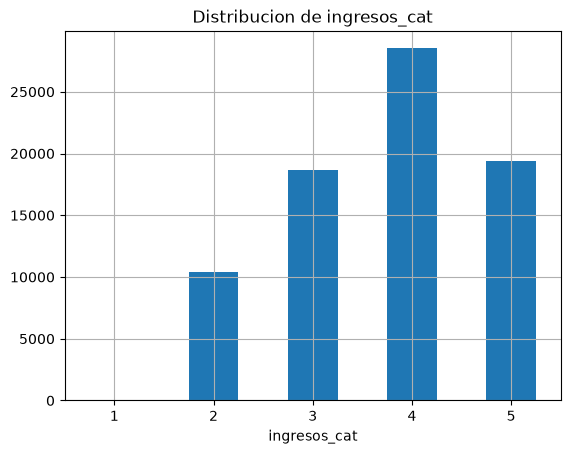

In [21]:
df_auto["ingresos_cat"] = pd.cut(
    df_auto["Ingresos"],
    bins=[0, 15000, 25000, 35000, 50000, np.inf],
    labels=[1, 2, 3, 4, 5]
)

df_auto["ingresos_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Distribucion de ingresos_cat")
plt.show()

In [22]:
train_no_strat, test_no_strat = train_test_split(
    df_auto, test_size=0.2, random_state=42, shuffle=True
)

train_strat_demo, test_strat_demo = train_test_split(
    df_auto, test_size=0.2, random_state=42, shuffle=True,
    stratify=df_auto["ingresos_cat"]
)

comparacion = pd.DataFrame({
    "Original": df_auto["ingresos_cat"].value_counts() / len(df_auto),
    "Train sin stratify": train_no_strat["ingresos_cat"].value_counts() / len(train_no_strat),
    "Train con stratify": train_strat_demo["ingresos_cat"].value_counts() / len(train_strat_demo)
})
comparacion

,Original,Train sin stratify,Train con stratify
ingresos_cat,,,
4,0.370535,0.368563,0.370529
5,0.252041,0.252019,0.252035
3,0.242447,0.244268,0.242448
2,0.134977,0.135150,0.134988
1,0.000000,0.000000,0.000000


In [23]:
df_auto = df_auto.drop(columns=["ingresos_cat"])
# ingresos_cat solo servia para esta comprobacion


estratificar mantiene mejor las proporciones originales, asi que en el split definitivo tambien estratificaremos (por impago, que es la variable que de verdad nos interesa de cara al modelo).

# Division train/test definitiva

Se hace antes de tratar outliers y de escalar, para que esos pasos se
puedan ajustar solo con train y aplicar despues a test. Estratificamos por impago, porque es una variable binaria con riesgo de desbalance,Prima es continua y train_test_split no puede estratificar
directamente por una variable continua pro se comprueba que, aun estratificando solo por impago ,la distribucion de prima queda parecida.

In [24]:
train_df, test_df = train_test_split(
    df_auto, test_size=0.2, random_state=42, stratify=df_auto["Impago"],shuffle=True
)
train_df = train_df.copy()
test_df = test_df.copy()

print("Train:", train_df.shape, " Test:", test_df.shape)
print("Impago en train:", train_df["Impago"].mean())
print("Impago en test:", test_df["Impago"].mean())
#compruebas que la separacion sea equilibrada


Train: (61539, 19)  Test: (15385, 19)
Impago en train: 0.11552023919790702
Impago en test: 0.11550211244718882


In [25]:
comparacion_prima = pd.DataFrame({
    "Train": train_df["Prima"].describe(),
    "Test": test_df["Prima"].describe()
})
comparacion_prima
#comparar estadisticas de prima entra train y test

,Train,Test
count,61539.000000,15385.000000
mean,383.927602,382.760729
std,267.440941,267.170982
min,10.000000,10.000000
25%,137.155000,137.060000
50%,333.030000,331.350000
75%,610.465000,612.320000
max,800.000000,800.000000


# Outliers

solo sobre train para no influencias decisiones de preprocesamiento por datos de test

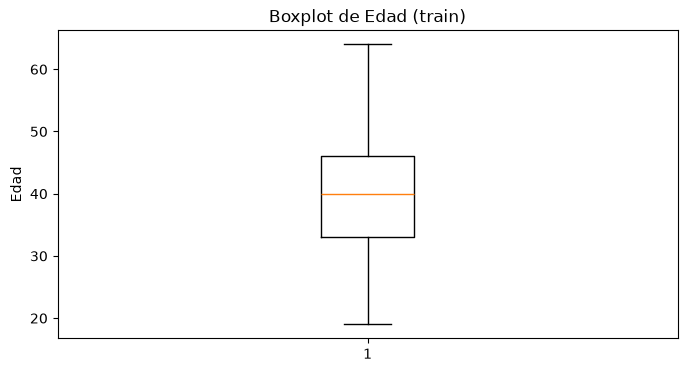

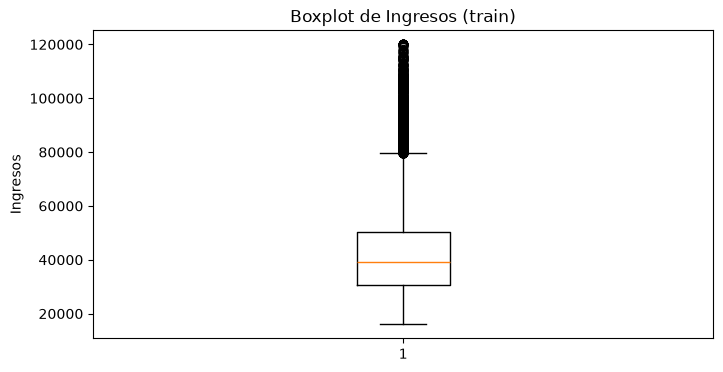

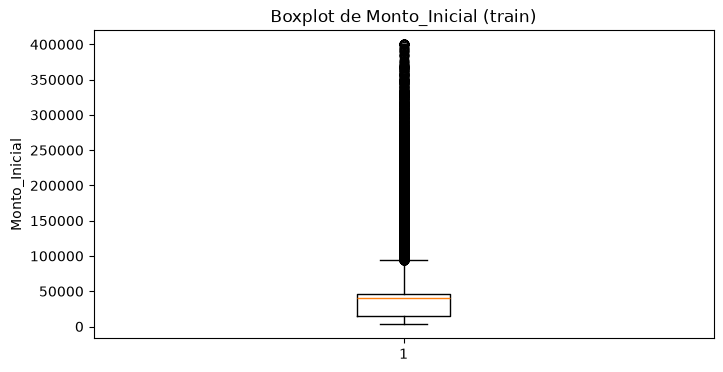

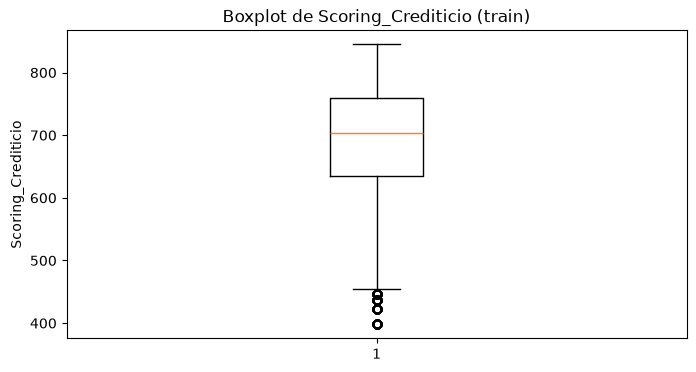

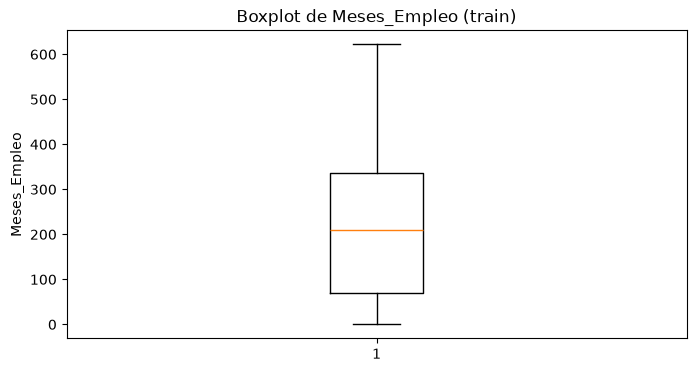

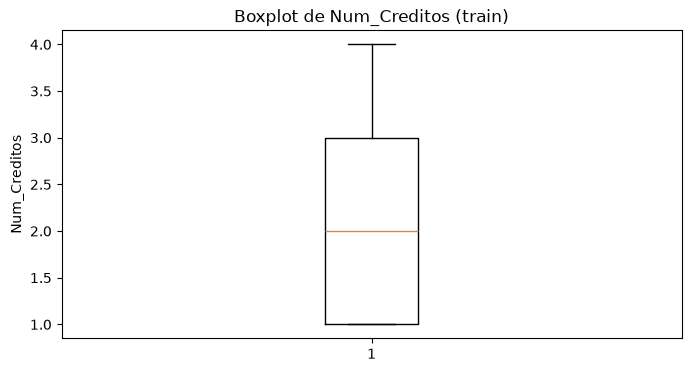

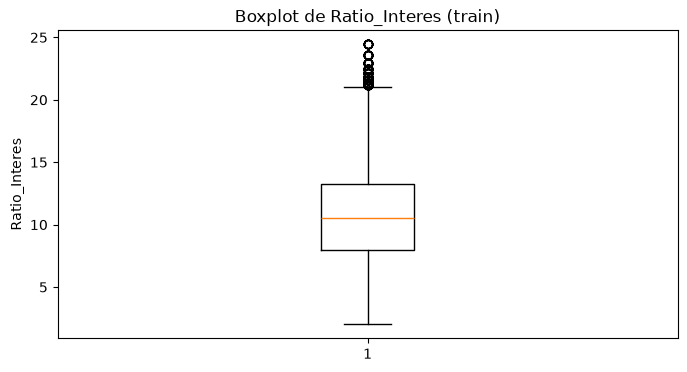

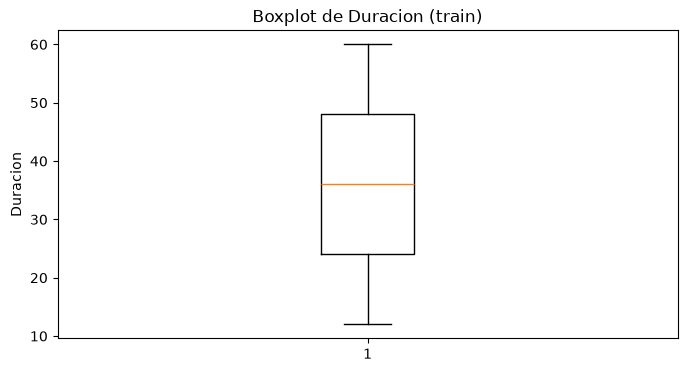

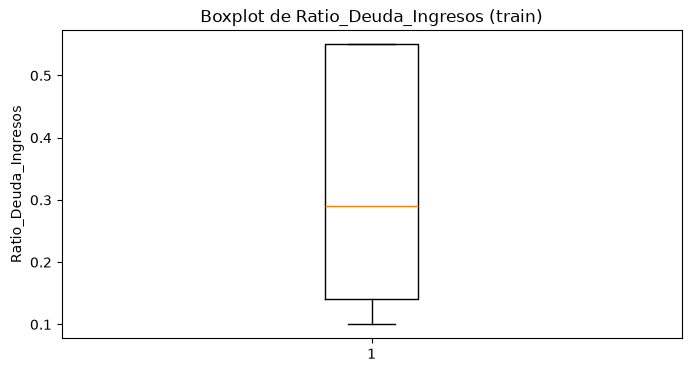

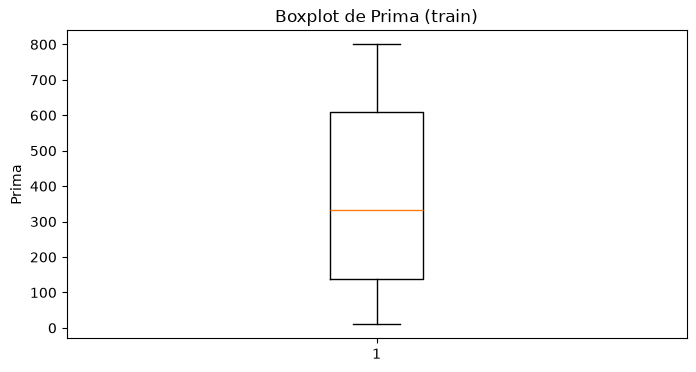

In [26]:
columnas_numericas = ["Edad", "Ingresos", "Monto_Inicial", "Scoring_Crediticio",
                      "Meses_Empleo", "Num_Creditos", "Ratio_Interes",
                      "Duracion", "Ratio_Deuda_Ingresos", "Prima"]

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    plt.boxplot(train_df[col].dropna())
    plt.title("Boxplot de " + col + " (train)")
    plt.ylabel(col)
    plt.show()
    #boxplot de cada variable numerica

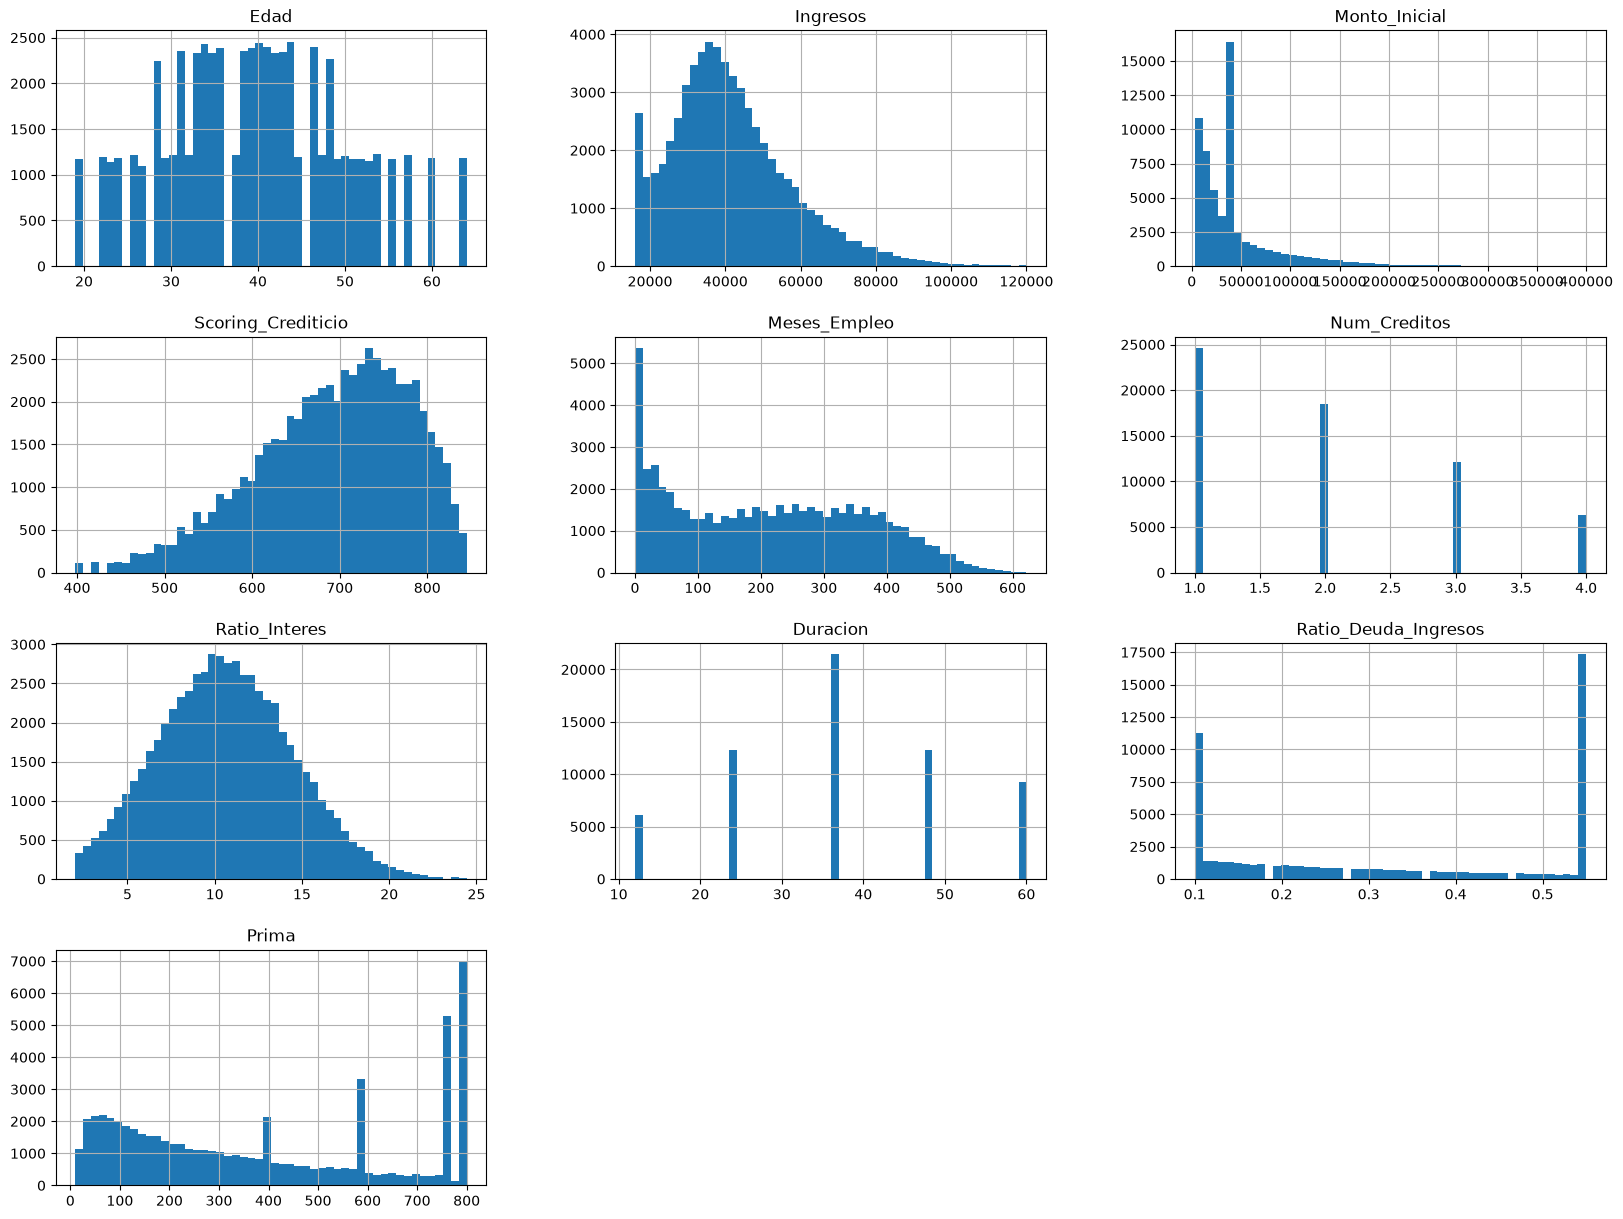

In [27]:
train_df[columnas_numericas].hist(bins=50, figsize=(20, 15))
plt.show()
#histogramas para ver formas y distribuciones

Para la detección de outliers se utilizó el criterio del rango intercuartílico (IQR × 1,5)
para el tratado recorte de Ingresos y Monto_Inicial se uso  un criterio de percentiles (1 % y 99 %), mas conservador.

In [28]:
# Porcentaje de outliers por columna, segun el criterio IQR
for col in columnas_numericas:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = train_df[(train_df[col] < limite_inferior) | (train_df[col] > limite_superior)]
    porcentaje = len(outliers) / len(train_df) * 100
    print(col, "-> outliers:", len(outliers), "  (", round(porcentaje, 2), "% )")

Edad -> outliers: 0   ( 0.0 % )
Ingresos -> outliers: 1615   ( 2.62 % )
Monto_Inicial -> outliers: 6897   ( 11.21 % )
Scoring_Crediticio -> outliers: 464   ( 0.75 % )
Meses_Empleo -> outliers: 0   ( 0.0 % )
Num_Creditos -> outliers: 0   ( 0.0 % )
Ratio_Interes -> outliers: 229   ( 0.37 % )
Duracion -> outliers: 0   ( 0.0 % )
Ratio_Deuda_Ingresos -> outliers: 0   ( 0.0 % )
Prima -> outliers: 0   ( 0.0 % )


In [29]:
# Analisis especifico de outliers en Monto_Inicial
q1_monto = train_df["Monto_Inicial"].quantile(0.25)
q3_monto = train_df["Monto_Inicial"].quantile(0.75)
iqr_monto = q3_monto - q1_monto
limite_superior_monto = q3_monto + 1.5 * iqr_monto

son_outliers = train_df["Monto_Inicial"] > limite_superior_monto
outliers_monto = train_df[son_outliers]
resto = train_df[~son_outliers]

print("Casos con Monto_Inicial outlier:", len(outliers_monto))
print()
print("Ingresos medios de los outliers:", round(outliers_monto["Ingresos"].mean()))
print("Ingresos medios de todos los demas:      ", round(resto["Ingresos"].mean()))
print()
print("Scoring medio de los outliers:", round(outliers_monto["Scoring_Crediticio"].mean()))
print("Scoring medio de todos los demas:      ", round(resto["Scoring_Crediticio"].mean()))
print()
print("Impago medio de los outliers:", round(outliers_monto["Impago"].mean(), 3))
print("Impago medio de todos los demas:      ", round(resto["Impago"].mean(), 3))

Casos con Monto_Inicial outlier: 6897

Ingresos medios de los outliers: 52055
Ingresos medios de todos los demas:       40290

Scoring medio de los outliers: 732
Scoring medio de todos los demas:       687

Impago medio de los outliers: 0.081
Impago medio de todos los demas:       0.12


In [30]:
# Ingresos 
limite_inferior_ingresos = train_df["Ingresos"].quantile(0.01)
limite_superior_ingresos = train_df["Ingresos"].quantile(0.99)

for data in (train_df, test_df):
    data.loc[data["Ingresos"] > limite_superior_ingresos, "Ingresos"] = limite_superior_ingresos
    data.loc[data["Ingresos"] < limite_inferior_ingresos, "Ingresos"] = limite_inferior_ingresos

# Monto_Inicial
train_df["Monto_Inicial"] = train_df["Monto_Inicial"].astype(float)
test_df["Monto_Inicial"] = test_df["Monto_Inicial"].astype(float)

limite_inferior_monto = train_df["Monto_Inicial"].quantile(0.01)
limite_superior_monto_99 = train_df["Monto_Inicial"].quantile(0.99)

for data in (train_df, test_df):
    data.loc[data["Monto_Inicial"] > limite_superior_monto_99, "Monto_Inicial"] = limite_superior_monto_99
    data.loc[data["Monto_Inicial"] < limite_inferior_monto, "Monto_Inicial"] = limite_inferior_monto

    
# Los limites (percentiles 1 % y 99 %) se calculan con train 
# se aplican igual a train y test asi el test no influye en el criterio de recorte

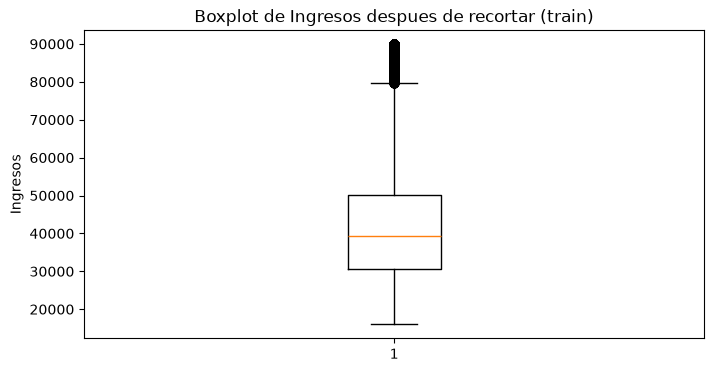

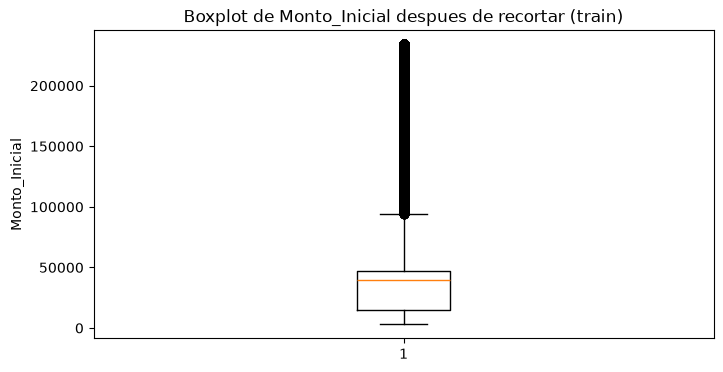

In [31]:
plt.figure(figsize=(8, 4))
plt.boxplot(train_df["Ingresos"].dropna())
plt.title("Boxplot de Ingresos despues de recortar (train)")
plt.ylabel("Ingresos")
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(train_df["Monto_Inicial"].dropna())
plt.title("Boxplot de Monto_Inicial despues de recortar (train)")
plt.ylabel("Monto_Inicial")
plt.show()

#boxplots despues de quitar outliers

# Estadistiocas descriptivas train (para ambos modelos)

In [32]:
train_df.describe()

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Posesion_Hipoteca,Fiador,Impago,Prima
count,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000,61539.000000
mean,39.700970,41517.243997,44259.550180,691.948813,213.176457,2.002632,10.650380,37.223614,0.319618,0.349859,0.301126,0.115520,383.927602
std,10.080869,15702.898310,43460.960477,87.687667,150.295273,1.003808,3.809536,14.167900,0.181047,0.476929,0.458751,0.319651,267.440941
min,19.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.000000,0.000000,10.000000
25%,33.000000,30558.000000,14980.500000,635.000000,70.000000,1.000000,7.940000,24.000000,0.140000,0.000000,0.000000,0.000000,137.155000
50%,40.000000,39191.000000,40000.000000,703.000000,209.000000,2.000000,10.550000,36.000000,0.290000,0.000000,0.000000,0.000000,333.030000
75%,46.000000,50188.500000,46776.500000,760.000000,337.000000,3.000000,13.230000,48.000000,0.550000,1.000000,1.000000,0.000000,610.465000
max,64.000000,89876.020000,234071.720000,845.000000,622.000000,4.000000,24.440000,60.000000,0.550000,1.000000,1.000000,1.000000,800.000000


NUMERICAS

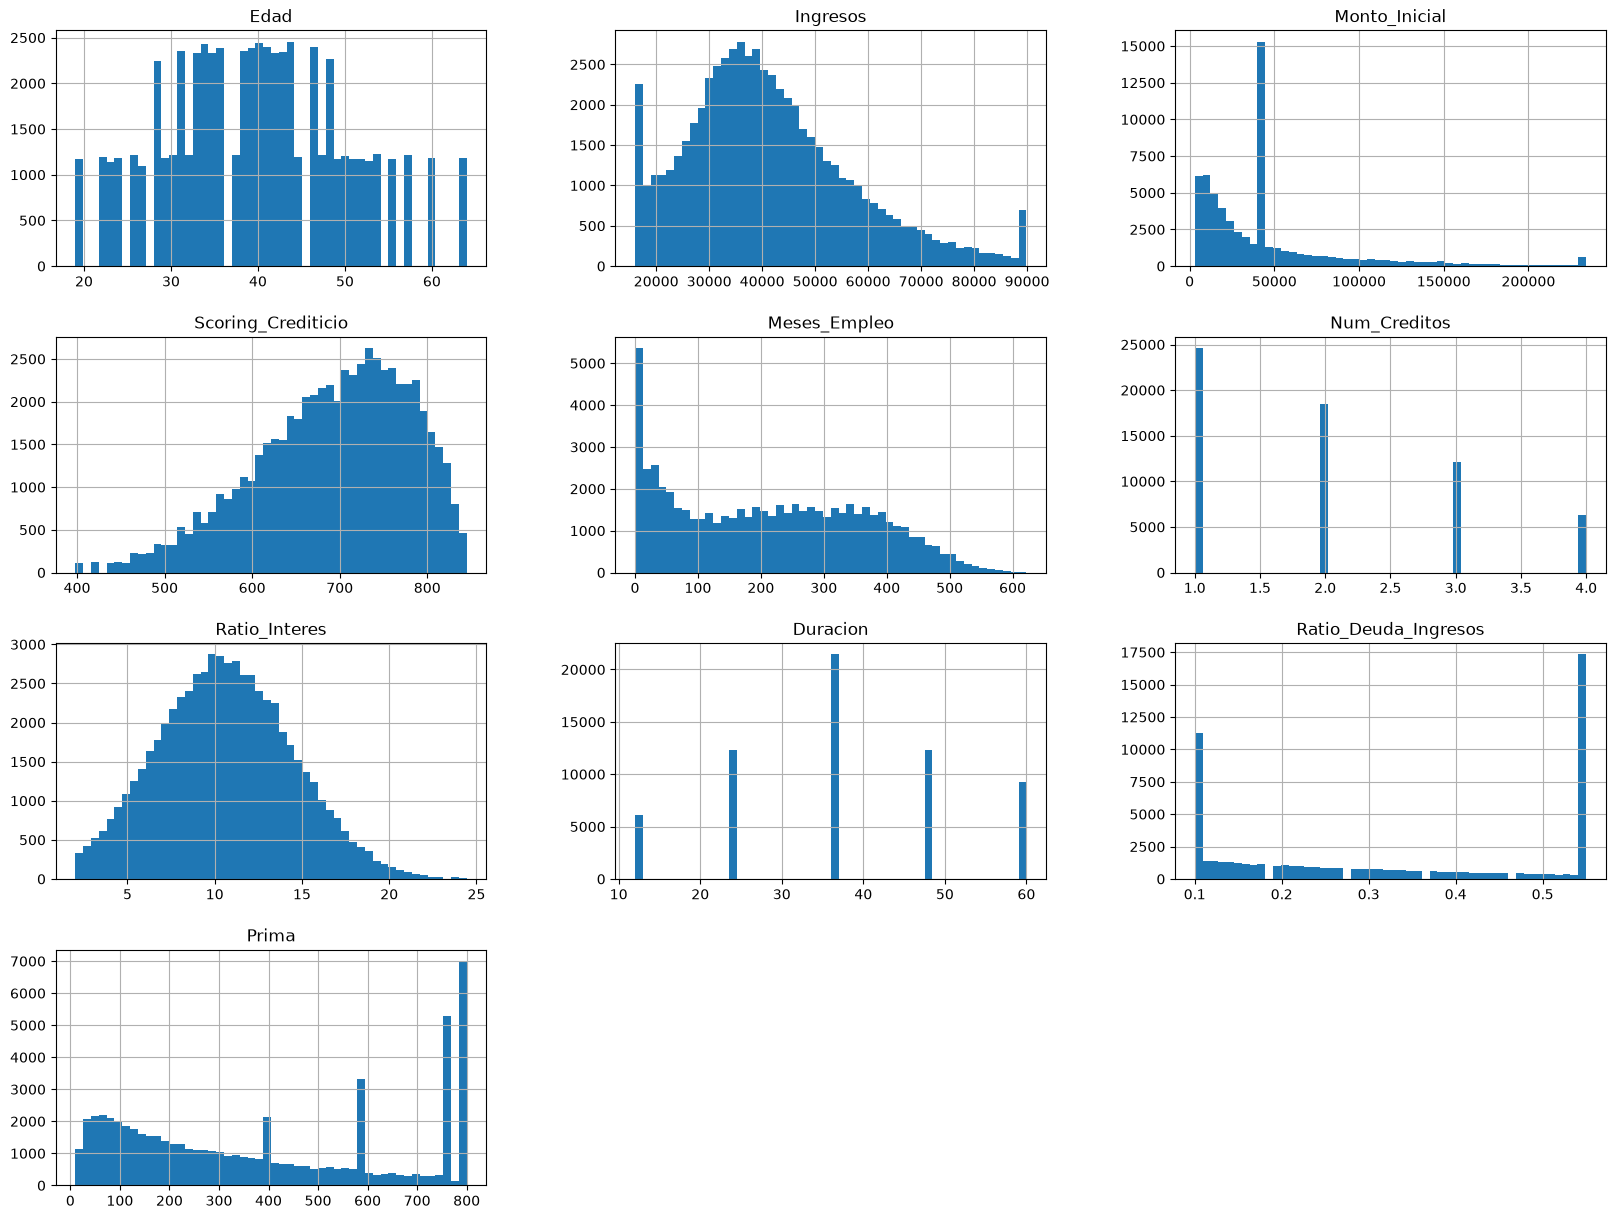

In [33]:
train_df[columnas_numericas].hist(bins=50, figsize=(20, 15))
plt.show()
# para ver la forma de cada variable: sesgo, outliers...

aqui veo que numeor de creditos y duracion estan discretizadas por lo que no me basare en person para decidir si seleccionarlas o no ya que solo detecta relaciones lineales

In [34]:
corr_matrix = train_df.corr(numeric_only=True)

print("Correlacion con Impago")
print(corr_matrix["Impago"].sort_values(ascending=False))
print()
print("Correlacion con Prima")
print(corr_matrix["Prima"].sort_values(ascending=False))
# ver correlacion de variables con impago y con prima

Correlacion con Impago
Impago                  1.000000
Ratio_Interes           0.126984
Posesion_Hipoteca       0.009151
Num_Creditos            0.000268
Fiador                 -0.000300
Duracion               -0.006971
Prima                  -0.018751
Ratio_Deuda_Ingresos   -0.024650
Scoring_Crediticio     -0.041950
Monto_Inicial          -0.050373
Ingresos               -0.084079
Meses_Empleo           -0.162833
Edad                   -0.167416
Name: Impago, dtype: float64

Correlacion con Prima
Prima                   1.000000
Monto_Inicial           0.655578
Ratio_Deuda_Ingresos    0.636028
Duracion                0.313938
Ingresos                0.213965
Ratio_Interes           0.138472
Edad                    0.113182
Meses_Empleo            0.083657
Posesion_Hipoteca      -0.000961
Fiador                 -0.002127
Num_Creditos           -0.003687
Impago                 -0.018751
Scoring_Crediticio     -0.070681
Name: Prima, dtype: float64


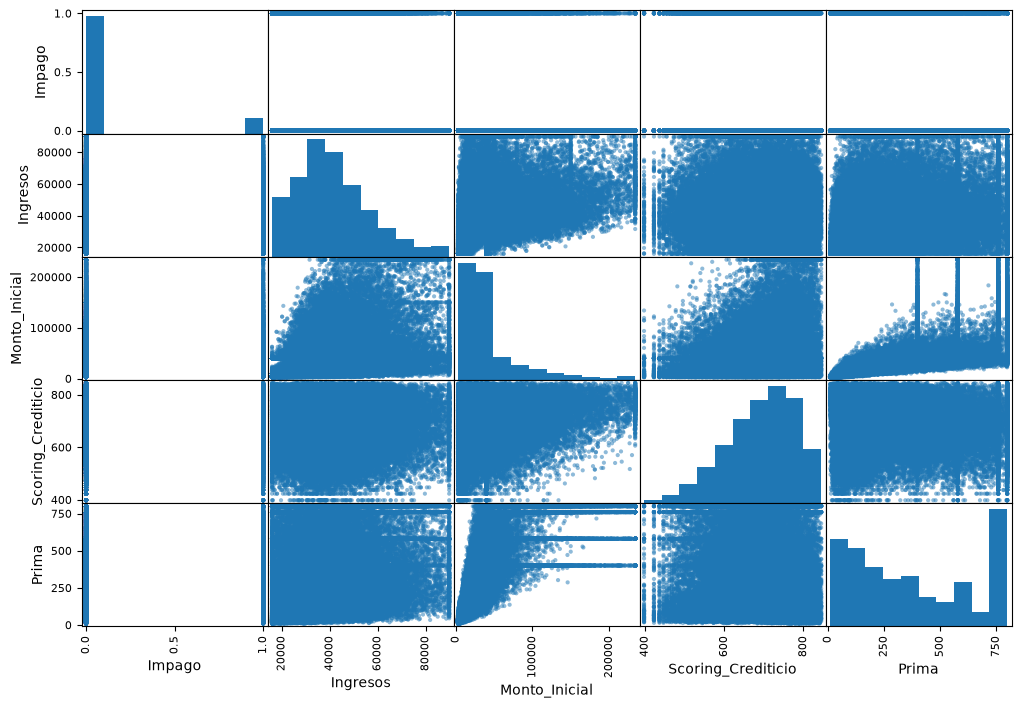

In [35]:

variables = ["Impago", "Ingresos", "Monto_Inicial", "Scoring_Crediticio", "Prima"]
scatter_matrix(train_df[variables], figsize=(12, 8))
plt.show()
# para ver relaciones visuales entre variables importantes (relaciones no lineales...)

CATEGORICAS

In [36]:
cat_features = ["Estudios", "Tipo_Jornada_Laboral", "Estado_Civil",
                "Posesion_Hipoteca", "Personas_Cargo", "Fiador"]

In [37]:
for col in cat_features:
    print("Tasa media de Impago por", col)
    print(train_df.groupby(col)["Impago"].mean().sort_values(ascending=False))
    print()
    print("Prima media por", col)
    print(train_df.groupby(col)["Prima"].mean().sort_values(ascending=False))
    print("-" * 50)

Tasa media de Impago por Estudios
Estudios
Grado Universitario    0.124940
Doctorado              0.121018
Máster                 0.118406
Escolar                0.104234
Name: Impago, dtype: float64

Prima media por Estudios
Estudios
Doctorado              457.046504
Máster                 437.263241
Grado Universitario    377.248943
Escolar                353.673382
Name: Prima, dtype: float64
--------------------------------------------------
Tasa media de Impago por Tipo_Jornada_Laboral
Tipo_Jornada_Laboral
Autónomo            0.121551
Jornada completa    0.114706
Desempleado         0.114106
Tiempo parcial      0.113966
Name: Impago, dtype: float64

Prima media por Tipo_Jornada_Laboral
Tipo_Jornada_Laboral
Desempleado         384.874413
Jornada completa    384.711043
Tiempo parcial      384.076959
Autónomo            380.219235
Name: Prima, dtype: float64
--------------------------------------------------
Tasa media de Impago por Estado_Civil
Estado_Civil
Soltero       0.167379
Ca

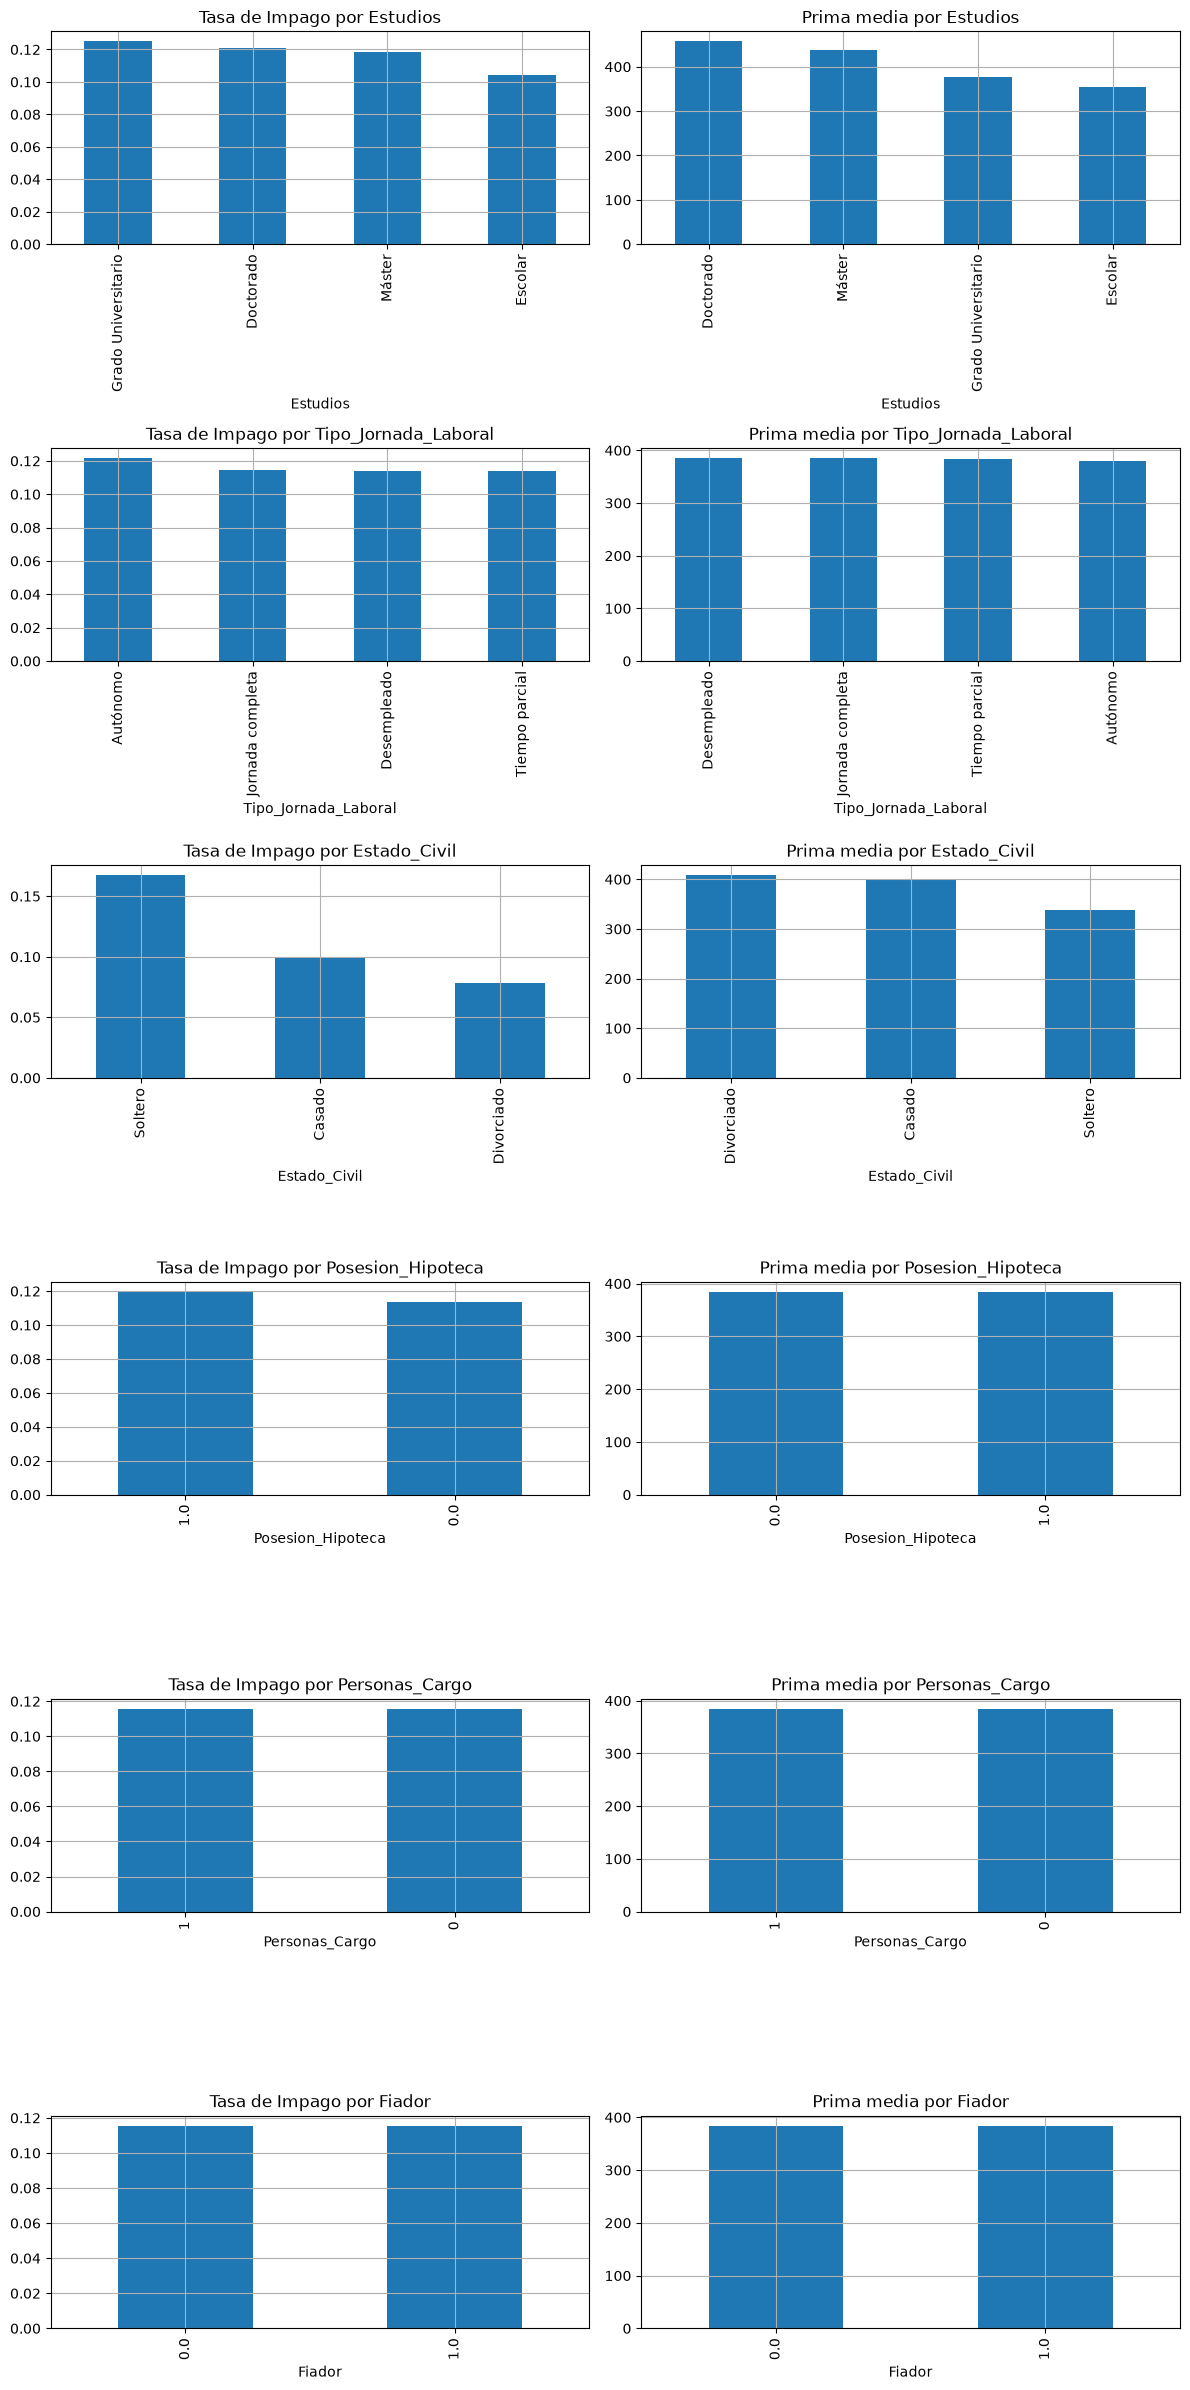

In [38]:
fig, axes = plt.subplots(len(cat_features), 2, figsize=(12, 4 * len(cat_features)))

for i, col in enumerate(cat_features):
    train_df.groupby(col)["Impago"].mean().sort_values(ascending=False).plot.bar(
        ax=axes[i, 0], grid=True, title=f"Tasa de Impago por {col}"
    )
    train_df.groupby(col)["Prima"].mean().sort_values(ascending=False).plot.bar(
        ax=axes[i, 1], grid=True, title=f"Prima media por {col}"
    )

plt.tight_layout()
plt.show()

SIGNIFICANCIA ESTADISTICA NUMERICAS (PEARSON +P-VALOR)

In [39]:
from scipy.stats import pearsonr

variables_numericas_para_test = ["Edad", "Ingresos", "Monto_Inicial", "Scoring_Crediticio",
                                  "Meses_Empleo", "Num_Creditos", "Ratio_Interes",
                                  "Duracion", "Ratio_Deuda_Ingresos", "Prima"]

resultados_impago = []
for col in variables_numericas_para_test:
    r, p = pearsonr(train_df[col], train_df["Impago"])
    resultados_impago.append({"variable": col, "correlacion": r, "p_valor": p})

resultados_impago_df = pd.DataFrame(resultados_impago).sort_values("p_valor")
resultados_impago_df

,variable,correlacion,p_valor
0,Edad,-0.167416,0.000000e+00
4,Meses_Empleo,-0.162833,0.000000e+00
6,Ratio_Interes,0.126984,1.502406e-219
1,Ingresos,-0.084079,6.054085e-97
2,Monto_Inicial,-0.050373,7.115334e-36
3,Scoring_Crediticio,-0.041950,2.212249e-25
8,Ratio_Deuda_Ingresos,-0.024650,9.610659e-10
9,Prima,-0.018751,3.289842e-06
7,Duracion,-0.006971,8.377260e-02
5,Num_Creditos,0.000268,9.470555e-01


In [40]:
# Prima no se prueba a si misma
variables_numericas_para_prima = [v for v in variables_numericas_para_test if v != "Prima"]

resultados_prima = []
for col in variables_numericas_para_prima:
    r, p = pearsonr(train_df[col], train_df["Prima"])
    resultados_prima.append({"variable": col, "correlacion": r, "p_valor": p})

resultados_prima_df = pd.DataFrame(resultados_prima).sort_values("p_valor")
resultados_prima_df

,variable,correlacion,p_valor
1,Ingresos,0.213965,0.000000e+00
2,Monto_Inicial,0.655578,0.000000e+00
7,Duracion,0.313938,0.000000e+00
8,Ratio_Deuda_Ingresos,0.636028,0.000000e+00
6,Ratio_Interes,0.138472,4.527657e-261
0,Edad,0.113182,1.476414e-174
4,Meses_Empleo,0.083657,5.452311e-96
3,Scoring_Crediticio,-0.070681,5.394651e-69
5,Num_Creditos,-0.003687,3.603922e-01


SIGNIFICANCIA ESTADISTICA CATEGORICAS (CHI-CUADRADO)

In [41]:
from scipy.stats import chi2_contingency

resultados_cat_impago = []
for col in cat_features:
    tabla_contingencia = pd.crosstab(train_df[col], train_df["Impago"])
    chi2, p, dof, esperado = chi2_contingency(tabla_contingencia)
    resultados_cat_impago.append({"variable": col, "chi2": chi2, "p_valor": p})

resultados_cat_impago_df = pd.DataFrame(resultados_cat_impago).sort_values("p_valor")
resultados_cat_impago_df

,variable,chi2,p_valor
2,Estado_Civil,717.790493,1.360739e-156
0,Estudios,52.002104,2.991990e-11
3,Posesion_Hipoteca,5.093334,2.401798e-02
1,Tipo_Jornada_Laboral,3.910851,2.712530e-01
4,Personas_Cargo,0.015029,9.024306e-01
5,Fiador,0.003676,9.516530e-01


In [42]:
prima_cat_temporal = pd.qcut(train_df["Prima"], q=4, labels=[1, 2, 3, 4])

resultados_cat_prima = []
for col in cat_features:
    tabla_contingencia = pd.crosstab(train_df[col], prima_cat_temporal)
    chi2, p, dof, esperado = chi2_contingency(tabla_contingencia)
    resultados_cat_prima.append({"variable": col, "chi2": chi2, "p_valor": p})

resultados_cat_prima_df = pd.DataFrame(resultados_cat_prima).sort_values("p_valor")
resultados_cat_prima_df

,variable,chi2,p_valor
0,Estudios,1487.583291,0.000000e+00
2,Estado_Civil,1312.478959,2.153940e-280
1,Tipo_Jornada_Laboral,15.919378,6.858440e-02
5,Fiador,2.015068,5.692851e-01
3,Posesion_Hipoteca,1.576516,6.647264e-01
4,Personas_Cargo,0.853225,8.366984e-01


# Preparacion para modelos

quitar columnas ID y proposito,codificar variables catgeoricas (no hace falta One Hot de sklearn por que no esperamos datos nuevos),alinemamos las columnas de train y test

In [43]:
cols_a_quitar = ["ID", "Proposito"]

train_model = train_df.drop(columns=cols_a_quitar)
test_model = test_df.drop(columns=cols_a_quitar)

In [44]:
train_encoded = pd.get_dummies(train_model, columns=cat_features, drop_first=True)
test_encoded = pd.get_dummies(test_model, columns=cat_features, drop_first=True)

# por si alguna  categoria solo aparece en un conjunto, se rellena con 0
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

train_encoded.shape, test_encoded.shape

((61539, 22), (15385, 22))

# Preparacion para modelo impago (clasificacion)

In [45]:
alpha = 0.05

# selección numéricas por Pearson
num_features_impago = resultados_impago_df.loc[
    resultados_impago_df["p_valor"] < alpha, "variable"
].tolist()

# añadir manualmente las numericas que se comportan como categoricas ya que pearson puede excluirlas sin razon 
extra_numeric = ["Duracion", "Num_Creditos"]
num_features_impago = list(set(num_features_impago + extra_numeric))

# selección categóricas por chi-cuadrado
cat_features_impago = resultados_cat_impago_df.loc[
    resultados_cat_impago_df["p_valor"] < alpha, "variable"
].tolist()

# columnas dummy que vienen de categóricas significativas
dummy_cols_impago = [c for c in train_encoded.columns
                      if any(c.startswith(cat + "_") for cat in cat_features_impago)]

print("Numericas usadas en Impago:", num_features_impago)
print("Categoricas usadas en Impago:", cat_features_impago)

columnas_impago = num_features_impago + dummy_cols_impago + ["Impago"]
train_impago = train_encoded[columnas_impago].copy()
test_impago = test_encoded[columnas_impago].copy()

# escalar solo numéricas
scaler_impago = StandardScaler()
train_impago[num_features_impago] = scaler_impago.fit_transform(train_impago[num_features_impago])
test_impago[num_features_impago] = scaler_impago.transform(test_impago[num_features_impago])

# separar X e y
X_train_impago = train_impago.drop(columns="Impago")
y_train_impago = train_impago["Impago"]

X_test_impago = test_impago.drop(columns="Impago")
y_test_impago = test_impago["Impago"]

X_train_impago.shape, X_test_impago.shape


Numericas usadas en Impago: ['Monto_Inicial', 'Duracion', 'Ratio_Deuda_Ingresos', 'Scoring_Crediticio', 'Meses_Empleo', 'Num_Creditos', 'Ingresos', 'Ratio_Interes', 'Edad', 'Prima']
Categoricas usadas en Impago: ['Estado_Civil', 'Estudios', 'Posesion_Hipoteca']


((61539, 16), (15385, 16))

# Preparacion para modelo prima (regresion)

In [46]:
# selección numéricas por Pearson
num_features_prima = resultados_prima_df.loc[
    resultados_prima_df["p_valor"] < alpha, "variable"
].tolist()

# añadir manualmente las numericas que se comportan como categoricas ya que pearson puede excluirlas sin razon 
extra_numeric = ["Duracion", "Num_Creditos"]
num_features_prima = list(set(num_features_prima + extra_numeric))

# selección categóricas por chi-cuadrado
cat_features_prima = resultados_cat_prima_df.loc[
    resultados_cat_prima_df["p_valor"] < alpha, "variable"
].tolist()

# columnas dummy que vienen de categóricas significativas
dummy_cols_prima = [c for c in train_encoded.columns
                     if any(c.startswith(cat + "_") for cat in cat_features_prima)]

print("Numericas usadas en Prima:", num_features_prima)
print("Categoricas usadas en Prima:", cat_features_prima)

columnas_prima = num_features_prima + dummy_cols_prima + ["Prima"]
train_prima = train_encoded[columnas_prima].copy()
test_prima = test_encoded[columnas_prima].copy()

# escalar solo numéricas
scaler_prima = StandardScaler()
train_prima[num_features_prima] = scaler_prima.fit_transform(train_prima[num_features_prima])
test_prima[num_features_prima] = scaler_prima.transform(test_prima[num_features_prima])

# separar X e y
X_train_prima = train_prima.drop(columns="Prima")
y_train_prima = train_prima["Prima"]

X_test_prima = test_prima.drop(columns="Prima")
y_test_prima = test_prima["Prima"]

X_train_prima.shape, X_test_prima.shape


Numericas usadas en Prima: ['Monto_Inicial', 'Duracion', 'Ratio_Deuda_Ingresos', 'Scoring_Crediticio', 'Meses_Empleo', 'Num_Creditos', 'Ingresos', 'Ratio_Interes', 'Edad']
Categoricas usadas en Prima: ['Estudios', 'Estado_Civil']


((61539, 14), (15385, 14))